# Medias Móviles en 2020
# Este notebook ejecuta el método de medias móviles sobre los datos del IBEX35
# Objetivo: calcular SMA/EMA y señales durante el año 2020 para su análisis y comparación.

In [2]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd().parent))

from load_data import DataProcessor
from medias_moviles import generate_ma_signals

print('Librerías importadas correctamente')

Librerías importadas correctamente


In [3]:
# Cargar datos usando DataProcessor y filtrar 2020
processor = DataProcessor()
df = processor.download_data()
processor.add_features()

# Filtrar solo 2020
df_2020 = df.loc['2020-01-01':'2020-12-31'].copy()
print('Filas en 2020:', df_2020.shape[0])
df_2020.head()

Descargando datos para ^IBEX...


[*********************100%***********************]  1 of 1 completed


Características añadidas. Columnas actuales: ['Close', 'High', 'Low', 'Open', 'Volume', 'Log_Ret', 'Volatilidad', 'RSI_14', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 'SMA_50', 'SMA_200']
Filas en 2020: 257


Price,Close,High,Low,Open,Volume,Log_Ret,Volatilidad,RSI_14,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9,SMA_50,SMA_200
Date,,,,,,,,,,,,,
2020-01-02,9691.200195,9705.400391,9615.099609,9639.099609,142379600,0.014761,0.007712,62.377484,91.007453,3.967993,87.039459,9399.666035,9213.933496
2020-01-03,9646.599609,9650.700195,9581.200195,9631.200195,135130000,-0.004613,0.007811,58.918249,88.033086,0.794901,87.238185,9404.994023,9215.388496
2020-01-06,9600.900391,9618.200195,9492.700195,9585.400391,103520400,-0.004749,0.007445,55.520741,81.053994,-4.947353,86.001346,9409.312031,9217.395996
2020-01-07,9579.799805,9657.900391,9557.900391,9623.099609,133476100,-0.002200,0.007422,53.973140,72.979114,-10.417786,83.396900,9413.072031,9219.395493
2020-01-08,9591.400391,9604.299805,9520.299805,9535.099609,133957600,0.001210,0.006744,54.720408,66.746374,-13.320421,80.066795,9416.296035,9221.436997


In [4]:
# Definir y ejecutar medias móviles sobre 2020
# Usamos SMA 50/200 por defecto pero se pueden ajustar
short_window = 50
long_window = 200

# Generar columnas de medias y señales
df_ma = generate_ma_signals(df_2020, short_window=short_window, long_window=long_window, column='Close', ma_type='SMA')

df_ma[['Close','MA_short','MA_long','signal']].tail()

Price,Close,MA_short,MA_long,signal
Date,,,,
2020-12-24,8111.500000,7623.725996,7169.747996,1
2020-12-28,8155.600098,7649.843994,7178.033496,1
2020-12-29,8174.799805,7676.135986,7187.533496,1
2020-12-30,8154.399902,7700.677988,7196.326497,1
2020-12-31,8073.700195,7725.921992,7204.478499,1


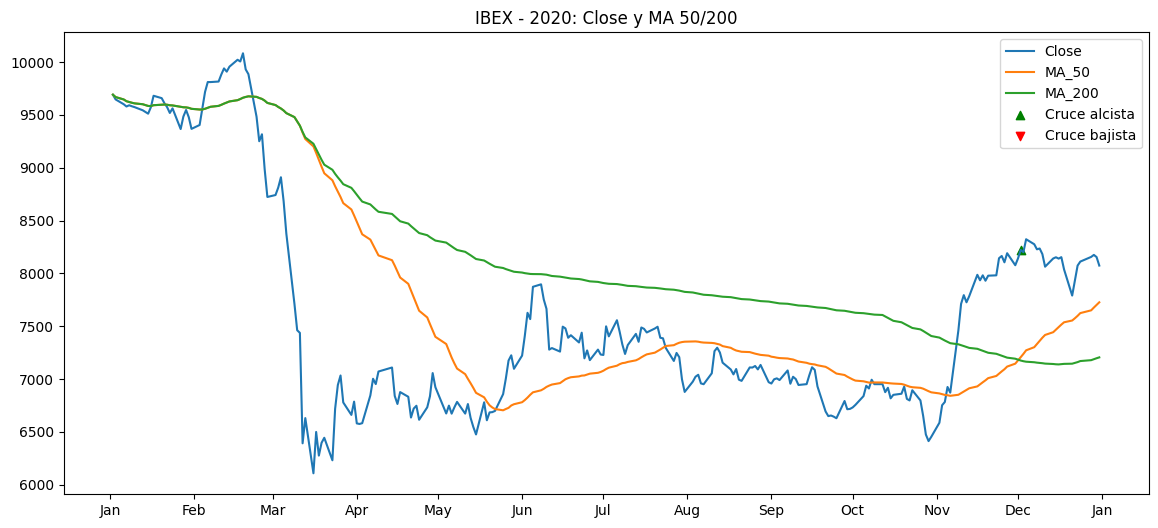

In [5]:
# Visualizar Close y Medias Móviles, marcando cruces
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14,6))
ax.plot(df_ma.index, df_ma['Close'], label='Close')
ax.plot(df_ma.index, df_ma['MA_short'], label=f'MA_{short_window}')
ax.plot(df_ma.index, df_ma['MA_long'], label=f'MA_{long_window}')

# Detectar cruces (diff==2 o -2)
bull = df_ma[df_ma['signal_change'] == 2]
bear = df_ma[df_ma['signal_change'] == -2]
ax.scatter(bull.index, df_ma.loc[bull.index,'Close'], marker='^', color='green', label='Cruce alcista')
ax.scatter(bear.index, df_ma.loc[bear.index,'Close'], marker='v', color='red', label='Cruce bajista')

ax.set_title(f'IBEX - 2020: Close y MA {short_window}/{long_window}')
ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.show()

Número aproximado de señales (cruces): 1


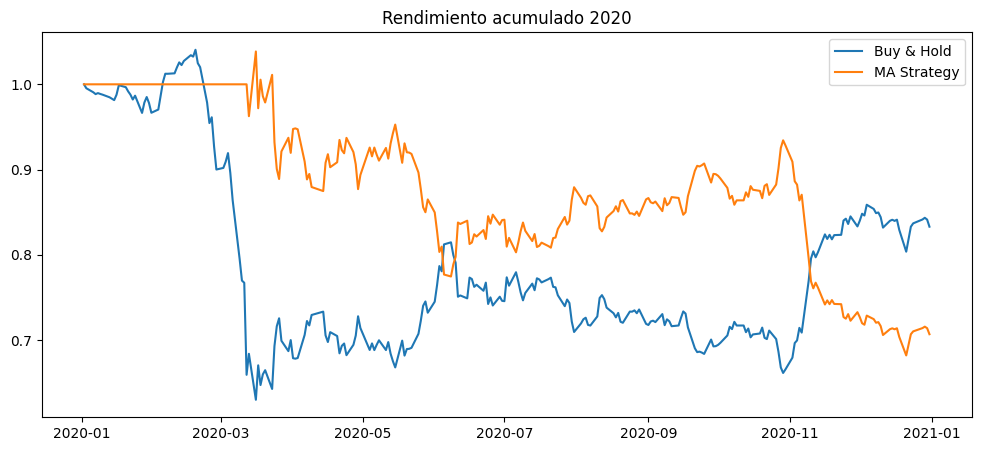

In [6]:
# Analizar rendimiento simple: estrategia basada en la señal vs buy-and-hold
# Retornos diarios

df_ma['ret'] = df_ma['Close'].pct_change().fillna(0)
# Estrategia: posición = signal del día anterior
df_ma['strategy_ret'] = df_ma['ret'] * df_ma['signal'].shift(1).fillna(0)

df_ma['cum_strategy'] = (1 + df_ma['strategy_ret']).cumprod()
df_ma['cum_buyhold'] = (1 + df_ma['ret']).cumprod()

print('Número aproximado de señales (cruces):', int(df_ma['signal_change'].abs().sum()/2))

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(df_ma.index, df_ma['cum_buyhold'], label='Buy & Hold')
ax.plot(df_ma.index, df_ma['cum_strategy'], label='MA Strategy')
ax.legend()
ax.set_title('Rendimiento acumulado 2020')
plt.show()

In [8]:
# Exportar resultados a CSV
output_path = 'C:\\Users\\Usuario\\TFM\\TFE\\notebooks\\medias_moviles_2020_results.csv'
df_ma.to_csv(output_path)
print(f'Resultados guardados en {output_path}')

Resultados guardados en C:\Users\Usuario\TFM\TFE\notebooks\medias_moviles_2020_results.csv


# Conclusión breve
# Este notebook muestra cómo calcular medias móviles y señales en 2020.
# Próximos pasos sugeridos:
# - Probar diferentes pares de ventanas (short/long)
# - Evaluar métricas más robustas (Sharpe, max drawdown)
# - Comparar con las anomalías detectadas por el CNN-AE
